In [1]:
import os
import random
import h5py

import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from torchinfo import summary
from sklearn.metrics import r2_score
import plotly.express as px


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split


import torchvision.transforms.functional as TF

import seaborn as sns
import matplotlib.pyplot as plt


sns.set_theme(style="ticks", palette="pastel", rc={"lines.linewidth": 2.5})

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "cudnn"):
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

generator = torch.Generator().manual_seed(SEED)

# Set the device to use for training
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Data

In [2]:
folder_path = "models/"

# Create the folder path and checkpoints directory if they don't exist
if not os.path.exists(folder_path):
    os.makedirs(folder_path)

if not os.path.exists(os.path.join(folder_path, "checkpoints")):
    os.makedirs(os.path.join(folder_path, "checkpoints"))

- Reading files

In [3]:
# modify so indices is the index of the dataframe
def read_hdf5_to_dataframe_with_index(h5_path="unified_parallel.h5"):
    with h5py.File(h5_path, "r") as f:
        viirs_start = f["viirs_start"][:]
        viirs_end = f["viirs_end"][:]
        rgb = f["rgb"][:]
        figures = f["figures"][:]
        indices = f["indices"][:]
        iso3 = f["iso3"][:]
        types = f["type"][:]

    # Decode bytes to strings for iso3
    iso3_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in iso3]
    types_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in types]

    # Create a DataFrame with indices as the index
    df = pd.DataFrame(
        {
            "viirs_start": list(viirs_start),
            "viirs_end": list(viirs_end),
            "rgb": list(rgb),
            "figures": figures,
            "iso3": iso3_decoded,
            "type": types_decoded,
        },
        index=indices,
    )

    df.sort_index(inplace=True)  # Ensure indices are sorted

    return df

In [4]:
path = "../src/data/processed/disaster.h5"
df_disaster = read_hdf5_to_dataframe_with_index(path)

path_idu = "../src/data/processed/testing.h5"
df_idu = read_hdf5_to_dataframe_with_index(path_idu)

# load csv iso3 embeddings
iso3_embeddings = pd.read_csv("../src/data/processed/embeddings_mapped.csv", index_col=0)

# combine the two dataframes
df = pd.concat([df_disaster, df_idu], ignore_index=True)

del df_disaster
del df_idu

In [5]:
len(df)

16896

In [6]:
iso3_embeddings.head()

,emb_0,emb_1,emb_2,emb_3
iso3_mapped,,,,
AND,-2.155526,-0.099045,1.090775,0.091681
ARE,-2.354902,-0.086402,1.196469,0.499288
AFG,2.381075,-0.013857,-0.791427,0.159821
ATG,-0.600651,-0.696483,-1.296734,1.598701
ALB,0.138654,-0.234058,-0.686938,-0.162994


In [7]:
# plot shape of df columns
print("Shape of DataFrame:", df.shape)
print("Columns in DataFrame:", df.columns)

Shape of DataFrame: (16896, 6)
Columns in DataFrame: Index(['viirs_start', 'viirs_end', 'rgb', 'figures', 'iso3', 'type'], dtype='object')


In [8]:
print(df["rgb"].iloc[0].shape)
print(df["viirs_start"].iloc[0].shape)
print(df["viirs_end"].iloc[0].shape)

(330, 330, 3)
(20, 20)
(20, 20)


In [17]:
import torch
import torch.nn as nn

class ViirsHybridCNN(nn.Module):
    def __init__(self, tabular_dim, rgb_stat_dim=8):
        super(ViirsHybridCNN, self).__init__()
        
        # 1. Tiny CNN for VIIRS (20x20)
        self.viirs_backbone = nn.Sequential(
            # CHANGED: in_channels is now 2 to handle [viirs_start, viirs_end]
            nn.Conv2d(2, 16, kernel_size=3, stride=1, padding=1, bias=False), 
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),                                     
            
            nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((2, 2))                         
        )
        
        # 2. Linear Head
        # VIIRS features = 32 channels * 2 * 2 = 128
        combined_dim = 128 + tabular_dim + rgb_stat_dim
        
        self.regressor = nn.Sequential(
            nn.Linear(combined_dim, 64, bias=False),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            # Added a small dropout; usually pairs well with BatchNorm in deep nets
            nn.Dropout(0.2), 
            nn.Linear(64, 1)
        )

    def forward(self, viirs, rgb_stats, tabular):
        # Process the 20x20 image (now 2 channels)
        v = self.viirs_backbone(viirs)
        v = v.view(v.size(0), -1) 
        
        # Concatenate with stats and embeddings
        combined = torch.cat((v, rgb_stats, tabular), dim=1)
        
        return self.regressor(combined)

In [18]:
def verify_data_sanity(df, embeddings, viirs_expected_size=400):
    """
    Scans the DataFrame and Embeddings to ensure all data types and shapes 
    are compatible with the ViirsHybridCNN pipeline.
    """
    print("="*50)
    print("🔍 INITIATING DATA SANITY CHECK")
    print("="*50)
    
    issues_found = 0
    
    # ---------------------------------------------------------
    # 1. Target (Figures) Check
    # ---------------------------------------------------------
    missing_targets = df["figures"].isna().sum()
    negative_targets = (df["figures"] < 0).sum()
    
    if missing_targets > 0:
        print(f"❌ ERROR: Found {missing_targets} missing target values (NaN).")
        issues_found += 1
    if negative_targets > 0:
        # np.log1p will fail/produce NaNs on values <= -1 
        print(f"⚠️ WARNING: Found {negative_targets} negative target values. Make sure np.log1p can handle them safely.")
        issues_found += 1

    # ---------------------------------------------------------
    # 2. Embeddings Validation
    # ---------------------------------------------------------
    missing_isos = df[~df["iso3"].isin(embeddings.index)]["iso3"].unique()
    if len(missing_isos) > 0:
        print(f"❌ ERROR: Missing embeddings for {len(missing_isos)} ISO3 codes: {missing_isos[:5]}...")
        issues_found += 1
        
    duplicate_isos = embeddings.index.duplicated().sum()
    if duplicate_isos > 0:
        print(f"⚠️ WARNING: Found {duplicate_isos} duplicate ISO3 codes in embeddings. The `.flatten()` fix in the Dataset will handle this, but it's better to clean the CSV.")
    
    # Ensure all embeddings have the same dimension
    embed_lengths = [len(np.array(row).flatten()) for _, row in embeddings.iterrows()]
    if len(set(embed_lengths)) > 1:
        print(f"❌ ERROR: Embeddings have inconsistent dimensions: {set(embed_lengths)}")
        issues_found += 1

    # ---------------------------------------------------------
    # 3. VIIRS Shape Check
    # ---------------------------------------------------------
    def check_viirs_shape(x):
        try:
            arr = np.array(x)
            return arr.size == viirs_expected_size
        except:
            return False

    invalid_viirs_start = (~df["viirs_start"].apply(check_viirs_shape)).sum()
    if invalid_viirs_start > 0:
        print(f"❌ ERROR: Found {invalid_viirs_start} 'viirs_start' arrays that do not have {viirs_expected_size} elements (required for 20x20 reshape).")
        issues_found += 1

    invalid_viirs_end = (~df["viirs_end"].apply(check_viirs_shape)).sum()
    if invalid_viirs_end > 0:
        print(f"❌ ERROR: Found {invalid_viirs_end} 'viirs_end' arrays that do not have {viirs_expected_size} elements.")
        issues_found += 1

    # ---------------------------------------------------------
    # 4. RGB Shape Check
    # ---------------------------------------------------------
    def check_rgb_validity(x):
        try:
            return np.array(x).size > 0
        except:
            return False
            
    empty_rgb = (~df["rgb"].apply(check_rgb_validity)).sum()
    if empty_rgb > 0:
        print(f"⚠️ WARNING: Found {empty_rgb} empty/invalid RGB arrays. The get_image_stats function will return zeros for these.")
        
    # ---------------------------------------------------------
    # Summary
    # ---------------------------------------------------------
    print("-" * 50)
    if issues_found == 0:
        print("✅ ALL CHECKS PASSED: Tensors and shapes look good!")
        return True
    else:
        print(f"🛑 FAILED: Please fix the {issues_found} critical errors above before training.")
        return False

In [11]:
verify_data_sanity(df, iso3_embeddings)

🔍 INITIATING DATA SANITY CHECK
❌ ERROR: Missing embeddings for 8 ISO3 codes: ['AB9' 'JEY' 'MAC' 'MYT' 'NAM']...
⚠️ WARNING: Found 19 duplicate ISO3 codes in embeddings. The `.flatten()` fix in the Dataset will handle this, but it's better to clean the CSV.
--------------------------------------------------
🛑 FAILED: Please fix the 1 critical errors above before training.


False

In [12]:
# remove from df the missing iso3 embeddings
missing_isos = df[~df["iso3"].isin(iso3_embeddings.index)]
print(f"Removing {len(missing_isos)} rows with missing ISO3 embeddings.")
df = df[df["iso3"].isin(iso3_embeddings.index)].reset_index(drop=True)

Removing 111 rows with missing ISO3 embeddings.


In [13]:
df

,viirs_start,viirs_end,rgb,figures,iso3,type
0,"[[0.12885213, 0.060012914, 0.16234863, 0.20263...","[[0.011053981, 0.05788457, 0.16050519, 0.20263...","[[[0.25909263, 0.20330623, 0.14005014], [0.249...",363.0,AFG,Drought
1,"[[0.039544035, 0.2250686, 0.16685954, 0.221493...","[[0.036352083, 0.19318436, 0.22394434, 0.23351...","[[[0.29722255, 0.2359766, 0.15761796], [0.2314...",402.0,AFG,Drought
2,"[[0.14396426, 0.08292116, 0.1306673, 0.2157852...","[[0.14396426, 0.08292116, 0.1306673, 0.2157852...","[[[0.24443644, 0.19616874, 0.1417105], [0.2198...",490.0,AFG,Drought
3,"[[0.37855563, 0.46555004, 0.4281328, 0.3079199...","[[0.37855563, 0.46555004, 0.4281328, 0.3079199...","[[[0.22977792, 0.18297495, 0.12874696], [0.221...",670.0,AFG,Drought
4,"[[0.27038977, 0.25043836, 0.20487599, 0.233189...","[[0.27038977, 0.25043836, 0.20487599, 0.233189...","[[[0.24475737, 0.20017499, 0.14016289], [0.247...",2051.0,AFG,Drought
...,...,...,...,...,...,...
16780,"[[1.5593433, 1.570583, 1.7917678, 1.9218643, 2...","[[1.0289657, 1.0315711, 1.297415, 1.2537636, 1...","[[[0.009154403, 0.02169776, 0.0076716603], [0....",268.0,NGA,Flood
16781,"[[1.7058152, 1.9792292, 1.7750238, 1.411087, 1...","[[2.0757854, 2.3944325, 2.379554, 1.6096739, 1...","[[[0.12351511, 0.105400026, 0.048240222], [0.1...",1050.0,NGA,Flood
16782,"[[0.76205915, 0.65495783, 0.52388334, 0.440400...","[[0.71229464, 0.6344576, 0.7872684, 0.7149165,...","[[[0.031535584, 0.053961206, 0.029882485], [0....",51058.0,NGA,Flood
16783,"[[0.61004126, 0.67480624, 0.598082, 0.5708878,...","[[1.0430839, 0.7390674, 0.7578583, 0.9156569, ...","[[[0.1302378, 0.14119597, 0.109257385], [0.090...",10321.0,NGA,Flood


In [ ]:
# %%
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from sklearn.model_selection import train_test_split

# First, extract all unique disaster types from the FULL dataframe
all_disaster_types = df["type"].unique()

class DisasterDataset(Dataset):
    def __init__(self, df, iso3_embeddings, all_types):
        self.df = df.reset_index(drop=True)
        self.embeddings = iso3_embeddings
        
        # Force pandas to recognize ALL possible categories, 
        # even if they aren't present in this specific split.
        self.df["type"] = pd.Categorical(self.df["type"], categories=all_types)
        self.type_dummies = pd.get_dummies(self.df["type"]).values.astype(np.float32)
        
    def __len__(self):
        return len(self.df)
        
    def get_image_stats(self, img_array):
        if img_array is None or len(img_array) == 0:
            return np.zeros(8, dtype=np.float32)
        
        img = np.array(img_array)
        if img.size == 0: return np.zeros(8, dtype=np.float32)
        flat = img.flatten()
        return np.array([
            np.mean(flat), np.std(flat), np.min(flat), np.max(flat),
            np.percentile(flat, 25), np.percentile(flat, 50),
            np.percentile(flat, 75), np.ptp(flat)
        ], dtype=np.float32)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # 1a. VIIRS Start
        viirs_s = np.array(row["viirs_start"], dtype=np.float32)
        if viirs_s.ndim == 2:
            viirs_s = np.expand_dims(viirs_s, axis=0) # shape (1, H, W)
        elif viirs_s.ndim == 1:
            viirs_s = viirs_s.reshape(1, 20, 20)
            
        # 1b. VIIRS End
        viirs_e = np.array(row["viirs_end"], dtype=np.float32)
        if viirs_e.ndim == 2:
            viirs_e = np.expand_dims(viirs_e, axis=0) # shape (1, H, W)
        elif viirs_e.ndim == 1:
            viirs_e = viirs_e.reshape(1, 20, 20)
            
        # 1c. Combine into a 2-channel tensor (Start, End) -> Shape (2, 20, 20)
        viirs_combined = np.concatenate([viirs_s, viirs_e], axis=0)
        viirs_tensor = torch.tensor(viirs_combined)
        
        # 2. RGB Stats
        rgb_stats = torch.tensor(self.get_image_stats(row["rgb"]))
        
        # 3. Tabular 
        embed_raw = self.embeddings.loc[row["iso3"]]
        if isinstance(embed_raw, pd.DataFrame):
            embed_raw = embed_raw.iloc[0]
        embed = embed_raw.values.astype(np.float32).flatten()
        
        type_dummy = self.type_dummies[idx]
        tabular_tensor = torch.tensor(np.concatenate([embed, type_dummy]))
        
        # 4. Target
        target = torch.tensor([np.log1p(row["figures"])], dtype=torch.float32)
        
        return viirs_tensor, rgb_stats, tabular_tensor, target

# ==========================================
# 1. Split Data (Train, Val, Test)
# ==========================================

# First split: Separate out the final test set (e.g., 10%)
train_val_df, test_df = train_test_split(df, test_size=0.1, random_state=SEED)

# Second split: Split the remaining data into Train and Validation (e.g., 80/20 of remaining)
train_df, val_df = train_test_split(train_val_df, test_size=0.1, random_state=SEED) 

# Create Datasets
train_dataset = DisasterDataset(train_df, iso3_embeddings, all_disaster_types)
val_dataset   = DisasterDataset(val_df,   iso3_embeddings, all_disaster_types)
test_dataset  = DisasterDataset(test_df,  iso3_embeddings, all_disaster_types)

# Create DataLoaders
batch_size = 256
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, generator=generator, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

print(f"Train size: {len(train_df)} | Val size: {len(val_df)} | Test size: {len(test_df)}")

# ==========================================
# 2. Initialize Model, Loss, and Optimizer
# ==========================================
# Grab one sample to determine tabular_dim
_, _, sample_tabular, _ = train_dataset[0]
tabular_dim = sample_tabular.shape[0]

# Initialize Model 
# IMPORTANT: Ensure ViirsHybridCNN's first Conv2d layer expects in_channels=2 now
model = ViirsHybridCNN(tabular_dim=tabular_dim, rgb_stat_dim=8).to(device)

# Loss and Optimizer
criterion = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-1, weight_decay=1e-5)

# ==========================================
# 3. The Training Loop
# ==========================================
epochs = 30
best_val_loss = float('inf')

for epoch in range(epochs):
    # --- Training Phase ---
    model.train()
    train_loss = 0.0
    
    for viirs, rgb, tab, targets in train_loader:
        # Move tensors to configured device
        viirs = viirs.to(device)
        rgb = rgb.to(device)
        tab = tab.to(device)
        targets = targets.to(device)
        
        # Forward pass
        preds = model(viirs, rgb, tab)
        loss = criterion(preds, targets)
        
        # Backward pass and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * viirs.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation Phase ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for viirs, rgb, tab, targets in val_loader:
            viirs = viirs.to(device)
            rgb = rgb.to(device)
            tab = tab.to(device)
            targets = targets.to(device)
            
            preds = model(viirs, rgb, tab)
            loss = criterion(preds, targets)
            val_loss += loss.item() * viirs.size(0)
            
    # FIXED: Was dividing by len(test_loader.dataset) previously
    val_loss /= len(val_loader.dataset) 
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # Simple Model Checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), os.path.join(folder_path, "checkpoints", "best_viirs_cnn.pth"))

Train size: 13595 | Val size: 1511 | Test size: 1679
Epoch [1/30] | Train Loss: 7.0716 | Val Loss: 5.8487
Epoch [2/30] | Train Loss: 5.9058 | Val Loss: 5.7286


In [27]:
# show sample of dataset from train_loader
sample_viirs, sample_rgb, sample_tab, sample_target = next(iter(train_loader))
print("Sample VIIRS shape:", sample_viirs.shape)  # Expecting (batch_size, 2, 20, 20)
print("Sample RGB stats shape:", sample_rgb.shape)  # Expecting (batch_size, 8)
print("Sample Tabular shape:", sample_tab.shape)  # Expecting (batch_size, tabular_dim)
print("Sample Target shape:", sample_target.shape)  # Expecting (batch_size, 1)

Sample VIIRS shape: torch.Size([164, 2, 20, 20])
Sample RGB stats shape: torch.Size([164, 8])
Sample Tabular shape: torch.Size([164, 16])
Sample Target shape: torch.Size([164, 1])


In [28]:
# =========================================================
# 0. GATHER PREDICTIONS (Fix for NameError)
# =========================================================
print("Gathering baseline predictions...")
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for viirs, rgb, tab, targets in test_loader:
        viirs = viirs.to(device)
        rgb = rgb.to(device)
        tab = tab.to(device)
        
        preds = model(viirs, rgb, tab)
        
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(targets.cpu().numpy().flatten())

y_true_np = np.array(all_targets)
y_pred_np = np.array(all_preds)

Gathering baseline predictions...


Calculating Bootstrapped Metrics...
Running Modality Ablation (Permutation Importance)...
Plotting diagnostics...


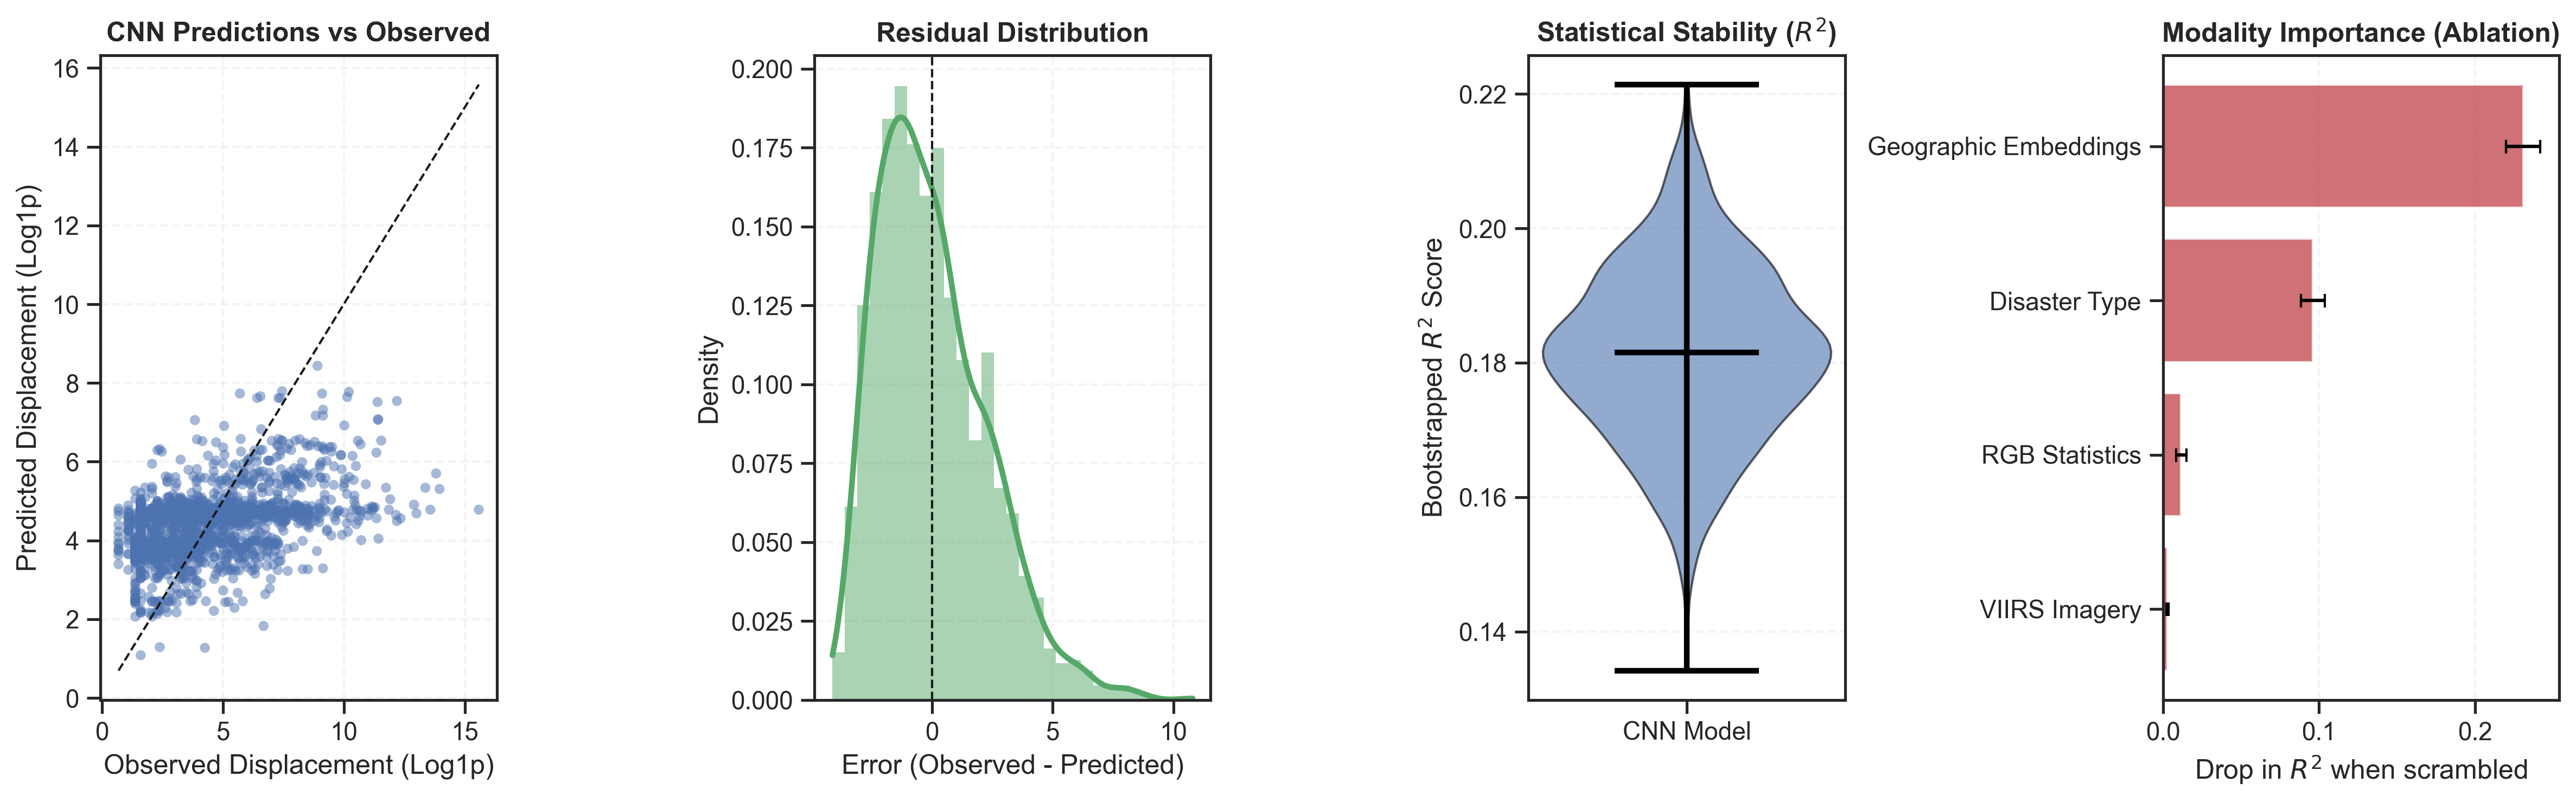

✅ Diagnostic report successfully saved to: CNN_Performance_Analysis.pdf


In [29]:
# %%
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =========================================================
# 1. BOOTSTRAP ANALYSIS (R2 STABILITY)
# =========================================================
print("Calculating Bootstrapped Metrics...")

def run_bootstrap_analysis_cnn(y_true, y_pred, n_iterations=1000):
    stats = {"R2": [], "MAE": [], "RMSE": []}
    rng = np.random.default_rng(SEED)
    
    for _ in range(n_iterations):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        y_t, y_p = y_true[idx], y_pred[idx]
        
        # Calculate and store metrics for this bootstrap sample
        stats["R2"].append(r2_score(y_t, y_p))
        stats["MAE"].append(mean_absolute_error(y_t, y_p))
        stats["RMSE"].append(np.sqrt(mean_squared_error(y_t, y_p)))
        
    return pd.DataFrame(stats)

y_true_np = np.array(all_targets)
y_pred_np = np.array(all_preds)
boot_cnn = run_bootstrap_analysis_cnn(y_true_np, y_pred_np)

# =========================================================
# 2. MODALITY ABLATION (FEATURE IMPORTANCE)
# =========================================================
print("Running Modality Ablation (Permutation Importance)...")

def calculate_ablation_importance(model, test_loader, base_r2, tabular_dim, n_repeats=10):
    model.eval()
    
    # 1. Gather all test data into large tensors
    all_v, all_r, all_t, all_y = [], [], [], []
    for v, r, t, y in test_loader:
        all_v.append(v)
        all_r.append(r)
        all_t.append(t)
        all_y.append(y)
        
    viirs = torch.cat(all_v)
    rgb = torch.cat(all_r)
    tab = torch.cat(all_t)
    targets = torch.cat(all_y).numpy().flatten()
    
    # Calculate where the embedding stops and the one-hot types begin
    num_disaster_types = len(all_disaster_types)
    embed_dim = tabular_dim - num_disaster_types
    
    importance_results = {}
    features_to_permute = {
        "VIIRS Imagery": "viirs",
        "RGB Statistics": "rgb",
        "Geographic Embeddings": "embed",
        "Disaster Type": "type"
    }
    
    for name, key in features_to_permute.items():
        drops = []
        for _ in range(n_repeats):
            # Generate a random shuffle index
            idx = torch.randperm(viirs.size(0))
            
            # Clone inputs so we don't permanently modify the original tensors
            v_perm, r_perm, t_perm = viirs.clone(), rgb.clone(), tab.clone()
            
            # Apply the shuffle to ONLY the specific modality
            if key == "viirs":
                v_perm = v_perm[idx]
            elif key == "rgb":
                r_perm = r_perm[idx]
            elif key == "embed":
                t_perm[:, :embed_dim] = t_perm[:, :embed_dim][idx]
            elif key == "type":
                t_perm[:, embed_dim:] = t_perm[:, embed_dim:][idx]
                
            # Run inference with the corrupted modality
            with torch.no_grad():
                preds = model(v_perm.to(device), r_perm.to(device), t_perm.to(device))
                preds = preds.cpu().numpy().flatten()
            
            # Record the drop in performance
            perm_r2 = r2_score(targets, preds)
            drops.append(base_r2 - perm_r2)
            
        importance_results[name] = {"importance_mean": np.mean(drops), "importance_std": np.std(drops)}
        
    # Convert to DataFrame
    df_imp = pd.DataFrame.from_dict(importance_results, orient="index").reset_index()
    df_imp = df_imp.rename(columns={"index": "display_name"})
    return df_imp

base_cnn_r2 = r2_score(y_true_np, y_pred_np)
imp_df = calculate_ablation_importance(model, test_loader, base_cnn_r2, tabular_dim)

# =========================================================
# 3. GENERATE 4-PANEL PDF DIAGNOSTIC PLOT
# =========================================================
print("Plotting diagnostics...")

def export_cnn_performance_pdf(y_test, y_pred, boot_df, imp_df, output_path="CNN_Performance_Analysis.pdf"):
    plt.rcParams.update({"font.family": "Arial", "font.size": 9})
    fig = plt.figure(figsize=(16, 5), dpi=300)
    gs = GridSpec(1, 4, width_ratios=[1, 1, 0.8, 1])

    # Panel 1: Scatter (Observed vs Predicted)
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.scatter(y_test, y_pred, s=20, alpha=0.5, color="#4C72B0", edgecolors='none')
    ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "--k", lw=1)
    ax1.set_title("CNN Predictions vs Observed", weight='bold')
    ax1.set_xlabel("Observed Displacement (Log1p)")
    ax1.set_ylabel("Predicted Displacement (Log1p)")
    ax1.grid(True, linestyle="--", alpha=0.2)
    
    # Panel 2: Error/Residual Distribution
    residuals = y_test - y_pred
    ax2 = fig.add_subplot(gs[0, 1])
    sns.histplot(residuals, kde=True, ax=ax2, color="#55A868", stat="density", linewidth=0)
    ax2.axvline(0, color='k', linestyle='--', lw=1)
    ax2.set_title("Residual Distribution", weight='bold')
    ax2.set_xlabel("Error (Observed - Predicted)")
    ax2.grid(True, linestyle="--", alpha=0.2)

    # Panel 3: R2 Stability (Bootstrap Violin)
    ax_boot = fig.add_subplot(gs[0, 2])
    v = ax_boot.violinplot([boot_df["R2"]], showmedians=True)
    for pc in v['bodies']:
        pc.set_facecolor("#4C72B0")
        pc.set_edgecolor('black')
        pc.set_alpha(0.6)
    v['cmedians'].set_color('black')
    v['cmins'].set_color('black')
    v['cmaxes'].set_color('black')
    v['cbars'].set_color('black')
    
    ax_boot.set_xticks([1])
    ax_boot.set_xticklabels(["CNN Model"])
    ax_boot.set_title("Statistical Stability ($R^2$)", weight='bold')
    ax_boot.set_ylabel("Bootstrapped $R^2$ Score")
    ax_boot.grid(True, axis='y', linestyle="--", alpha=0.2)

    # Panel 4: Modality Ablation Importance
    ax_imp = fig.add_subplot(gs[0, 3])
    # Sort ascending so the most important feature is at the top of the horizontal bar chart
    imp_df_sorted = imp_df.sort_values("importance_mean", ascending=True)
    
    ax_imp.barh(imp_df_sorted["display_name"], 
                imp_df_sorted["importance_mean"], 
                xerr=imp_df_sorted["importance_std"], 
                color="#C44E52",
                alpha=0.8,
                error_kw={'capsize': 3, 'elinewidth': 1.5, 'ecolor': 'black'})
                
    ax_imp.set_title("Modality Importance (Ablation)", weight='bold')
    ax_imp.set_xlabel("Drop in $R^2$ when scrambled")
    ax_imp.grid(True, axis='x', linestyle="--", alpha=0.2)

    plt.tight_layout()
    plt.savefig(output_path, format='pdf', bbox_inches='tight')
    plt.show()
    print(f"✅ Diagnostic report successfully saved to: {output_path}")

export_cnn_performance_pdf(y_true_np, y_pred_np, boot_cnn, imp_df)

In [30]:
# %%
import torch
import numpy as np
import pandas as pd
from sklearn.metrics import r2_score
import plotly.express as px
import plotly.graph_objects as go

# =========================================================
# 1. GATHER PREDICTIONS FROM THE CNN
# =========================================================
print("Running inference on the test set...")
model.eval()
all_preds = []
all_targets = []

with torch.no_grad():
    for viirs, rgb, tab, targets in test_loader:
        # Move tensors to device
        viirs = viirs.to(device)
        rgb = rgb.to(device)
        tab = tab.to(device)
        
        # Forward pass
        preds = model(viirs, rgb, tab)
        
        # Move back to CPU and convert to flat numpy arrays
        all_preds.extend(preds.cpu().numpy().flatten())
        all_targets.extend(targets.cpu().numpy().flatten())

# =========================================================
# 2. BUILD RESULTS DATAFRAME
# =========================================================
# Since test_loader has shuffle=False, it perfectly aligns with test_df
results_cnn_df = pd.DataFrame({
    'iso3': test_df['iso3'].values,
    'type': test_df['type'].values,
    'y_true': all_targets,
    'y_pred_cnn': all_preds
})

# Safe R2 function requires at least 2 samples to calculate variance
def safe_r2(g, pred_col):
    if len(g) > 1:
        return r2_score(g['y_true'], g[pred_col])
    return np.nan

# Calculate R2 per Country and Type
r2_by_country_cnn = results_cnn_df.groupby('iso3').apply(lambda g: safe_r2(g, 'y_pred_cnn')).dropna().sort_values(ascending=False)
r2_by_type_cnn = results_cnn_df.groupby('type').apply(lambda g: safe_r2(g, 'y_pred_cnn')).dropna().sort_values(ascending=False)

# =========================================================
# 3. FIGURE 1: CHOROPLETH MAP
# =========================================================
print("Generating Choropleth Map...")
r2_country_df = r2_by_country_cnn.reset_index()
r2_country_df.columns = ["iso3", "r2"]

fig_map = px.choropleth(
    r2_country_df,
    locations="iso3",
    color="r2",
    hover_name="iso3",
    hover_data={"r2": ":.4f", "iso3": False},
    color_continuous_scale="RdYlGn",
    range_color=[-0.2, 0.8], # Keeping the same scale as XGBoost for direct comparison
    labels={"r2": "R² Score"}
)

fig_map.update_geos(
    projection_type="natural earth",
    showframe=True,
    showcoastlines=True,
    coastlinecolor="RebeccaPurple",
    showland=True,
    landcolor="rgb(243, 243, 243)",
    bgcolor="rgba(240, 248, 255, 0.5)"
)

fig_map.update_layout(
    template="plotly_white",
    height=600,
    width=1200,
    margin=dict(l=10, r=10, t=80, b=10),
    font=dict(family="Arial", size=12, color="black"),
    title=dict(
        text="CNN Model Performance: R² Score by Country<br><sub>Deep learning predictions for climate-displaced populations</sub>",
        x=0.01,
        xanchor="left",
        font=dict(size=15, color="black", family="Arial")
    ),
    coloraxis_colorbar=dict(
        title="R² Score",
        thickness=20,
        len=0.7,
        x=1.02,
        outlinewidth=2,
        outlinecolor="black",
        tickformat=".2f",
        tickfont=dict(size=11)
    ),
)

fig_map.write_html("CNN_R2_Choropleth_Map.html")
# fig_map.write_image("CNN_R2_Choropleth_Map.pdf", engine="kaleido") # Uncomment if kaleido is installed
fig_map.show()

# =========================================================
# 4. FIGURE 2: DISASTER TYPE PERFORMANCE
# =========================================================
print("Generating Disaster Type Bar Chart...")
type_counts = results_cnn_df.groupby('type').size().reset_index(name='count')
r2_type_df = r2_by_type_cnn.reset_index()
r2_type_df.columns = ["type", "r2"]
r2_type_df = r2_type_df.merge(type_counts, on="type")

# Sort by R2 descending for the plot
r2_type_df = r2_type_df.sort_values("r2", ascending=True)

# Color function based on performance thresholds
def get_color(r2):
    if r2 > 0.6:
        return "#1f77b4"  # Blue - excellent
    elif r2 > 0.4:
        return "#2ca02c"  # Green - good
    elif r2 > 0:
        return "#ff7f0e"  # Orange - moderate
    else:
        return "#d62728"  # Red - poor

colors_type = [get_color(x) for x in r2_type_df["r2"]]

fig_type = go.Figure(data=[
    go.Bar(
        y=r2_type_df["type"],
        x=r2_type_df["r2"],
        orientation='h',
        marker=dict(
            color=colors_type,
            line=dict(color="black", width=1.5)
        ),
        text=[f"R²: {r2:.3f}<br>n={count}" for r2, count in zip(r2_type_df["r2"], r2_type_df["count"])],
        textposition="outside",
        hovertemplate="<b>%{y}</b><br>R² Score: %{x:.4f}<extra></extra>",
        showlegend=False
    )
])

fig_type.update_layout(
    template="plotly_white",
    height=500,
    width=900,
    margin=dict(l=150, r=150, t=80, b=50),
    font=dict(family="Arial", size=12, color="black"),
    title=dict(
        text="CNN Model Performance Stratified by Disaster Type<br><sub>Evaluating spatial feature extraction efficacy across event types</sub>",
        x=0.0,
        xanchor="left",
        font=dict(size=14, color="black")
    ),
    xaxis=dict(
        title="R² Score",
        showgrid=True,
        gridwidth=1,
        gridcolor="rgba(128,128,128,0.2)",
        zeroline=True,
        zerolinewidth=2,
        zerolinecolor="black"
    ),
    yaxis=dict(
        title="Disaster Type",
        showgrid=False,
    ),
)

fig_type.write_html("CNN_R2_by_DisasterType.html")
# fig_type.write_image("CNN_R2_by_DisasterType.pdf", engine="kaleido") # Uncomment if kaleido is installed
fig_type.show()

# =========================================================
# 5. PRINT SUMMARY
# =========================================================
print("\n" + "="*70)
print("CNN R² PERFORMANCE ANALYSIS COMPLETE")
print("="*70)
print(f"\n📊 GEOGRAPHIC INSIGHTS (CNN):")
print(f"  • Countries analyzed: {len(r2_by_country_cnn)}")
print(f"  • Countries with positive R²: {(r2_by_country_cnn > 0).sum()}")
if not r2_by_country_cnn.empty:
    print(f"  • Mean R² (all countries): {r2_by_country_cnn.mean():.4f}")
    print(f"  • Best performing country: {r2_by_country_cnn.idxmax()} (R² = {r2_by_country_cnn.max():.4f})")

print(f"\n⚠️  DISASTER TYPE INSIGHTS (CNN):")
print(f"  • Disaster types: {len(r2_by_type_cnn)}")
print(f"  • Types with positive R²: {(r2_by_type_cnn > 0).sum()}")
if not r2_by_type_cnn.empty:
    print(f"  • Best type: {r2_by_type_cnn.idxmax()} (R² = {r2_by_type_cnn.max():.4f})")
    print(f"  • Most challenging: {r2_by_type_cnn.idxmin()} (R² = {r2_by_type_cnn.min():.4f})")
print("="*70)

Running inference on the test set...
Generating Choropleth Map...


/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_40976/1285164811.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_country_cnn = results_cnn_df.groupby('iso3').apply(lambda g: safe_r2(g, 'y_pred_cnn')).dropna().sort_values(ascending=False)
/var/folders/ys/5gn1z90x7c1_khtjpp5kg6580000gn/T/ipykernel_40976/1285164811.py:50: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  r2_by_type_cnn = results_cnn_df

Generating Disaster Type Bar Chart...



CNN R² PERFORMANCE ANALYSIS COMPLETE

📊 GEOGRAPHIC INSIGHTS (CNN):
  • Countries analyzed: 89
  • Countries with positive R²: 12
  • Mean R² (all countries): -5.2432
  • Best performing country: IRN (R² = 0.6868)

⚠️  DISASTER TYPE INSIGHTS (CNN):
  • Disaster types: 10
  • Types with positive R²: 9
  • Best type: Mixed disasters (R² = 0.5658)
  • Most challenging: Volcanic activity (R² = -1.3716)
